# 05 — Feature Engineering Candidates

**Amaç:** Ratio, missing, outlier, interaction ve rule-based feature adaylarını target ile değerlendirmek.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from kaggle_s6_e7.config import (FIGURES_DIR, TABLES_DIR, TARGET_COL, ID_COL,
    PLOT_SAMPLE_SIZE, RANDOM_STATE, ensure_report_dirs)
from kaggle_s6_e7.data import load_competition_data, infer_feature_columns, validate_schema
ensure_report_dirs()
train, test = load_competition_data()
validate_schema(train, test)
cat_cols, num_cols = infer_feature_columns(train)
plot_df = train.sample(min(PLOT_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")

## Aday feature setini üret

In [2]:
from kaggle_s6_e7.features import (add_ratio_features,add_missing_features,add_categorical_interactions,
    add_rule_features,fit_outlier_bounds,add_outlier_flags)
feature_cols=[c for c in train if c not in [ID_COL,TARGET_COL]]
train_fe=add_ratio_features(train)
train_fe=add_missing_features(train_fe,feature_cols)
train_fe=add_categorical_interactions(train_fe)
train_fe=add_rule_features(train_fe)
ratio_cols=["calorie_per_step","calorie_per_exercise_min","step_per_exercise_min",
            "water_per_bmi","exercise_per_bmi","steps_per_sleep_hour"]
bounds=fit_outlier_bounds(train_fe,num_cols+ratio_cols)
train_fe=add_outlier_flags(train_fe,bounds)
print("Yeni kolon sayısı:",len(train_fe.columns)-len(train.columns))

Yeni kolon sayısı: 59


## Ratio dağılımları ve target ilişkisi

health_condition                      at-risk           fit     unhealthy
calorie_per_step         count  536148.000000  36003.000000  52239.000000
                         mean        0.375448      0.218121      0.364334
                         std         0.319075      0.091897      0.309390
                         min         0.112893      0.116801      0.118331
                         1%          0.140727      0.133439      0.142349
                         5%          0.156001      0.147085      0.156560
                         50%         0.259240      0.198099      0.253640
                         95%         1.099643      0.341715      1.041198
                         99%         1.734064      0.459553      1.710144
                         max         2.597453      2.301602      2.521989
calorie_per_exercise_min count  541772.000000  36343.000000  52721.000000
                         mean      121.845735     50.540136    116.860915
                         std       330.882252     67.956921    320.494960
                         min        21.946387     21.365228     23.015134
                         1%         32.152985     29.932618     32.068125
                         5%         36.357334     33.385360     36.233333
                         50%        55.857916     46.241830     55.268199
                         95%       143.333333     69.232666    133.560606
                         99%      2166.000000     81.714153   2140.800000
                         max      2690.000000   2477.000000   2636.000000
step_per_exercise_min    count  574806.000000  38600.000000  55996.000000
                         mean      383.797286    243.463633    370.288386
                         std      1011.485187    194.291933    969.501753
                         min        20.000000     23.881279     20.652174
                         1%         34.946498     97.100120     35.545696
                         5%         62.017837    126.005178     64.707110
                         50%       217.758884    231.170703    219.358765
                         95%       542.204412    373.674676    511.422340
                         99%      6491.000000    436.148088   6088.838462
                         max     12387.000000  10256.000000  12292.000000
water_per_bmi            count  543818.000000  36203.000000  53557.000000
                         mean        0.092366      0.096778      0.088010
                         std         0.023964      0.026586      0.022714
                         min         0.015985      0.019040      0.016056
                         1%          0.034978      0.037599      0.034302
                         5%          0.057175      0.059125      0.053649
                         50%         0.090798      0.094083      0.087007
                         95%         0.134624      0.144189      0.128226
                         99%         0.155923      0.171229      0.146684
                         max         0.236934      0.239412      0.199811
exercise_per_bmi         count  574449.000000  38260.000000  56710.000000
                         mean        1.602444      2.223000      1.569668
                         std         0.644848      0.544836      0.612177
                         min         0.000000      0.000000      0.000000
                         1%          0.000000      1.164152      0.000000
                         5%          0.557565      1.410147      0.585391
                         50%         1.611665      2.206111      1.578428
                         95%         2.629827      3.166580      2.543187
                         99%         3.034032      3.607985      2.878137
                         max         4.339623      4.780702      3.900047
steps_per_sleep_hour     count  516596.000000  34738.000000  50380.000000
                         mean     1064.044667   1309.048928   1378.940367
                         std       531.259151    316.231829    647.143498
    

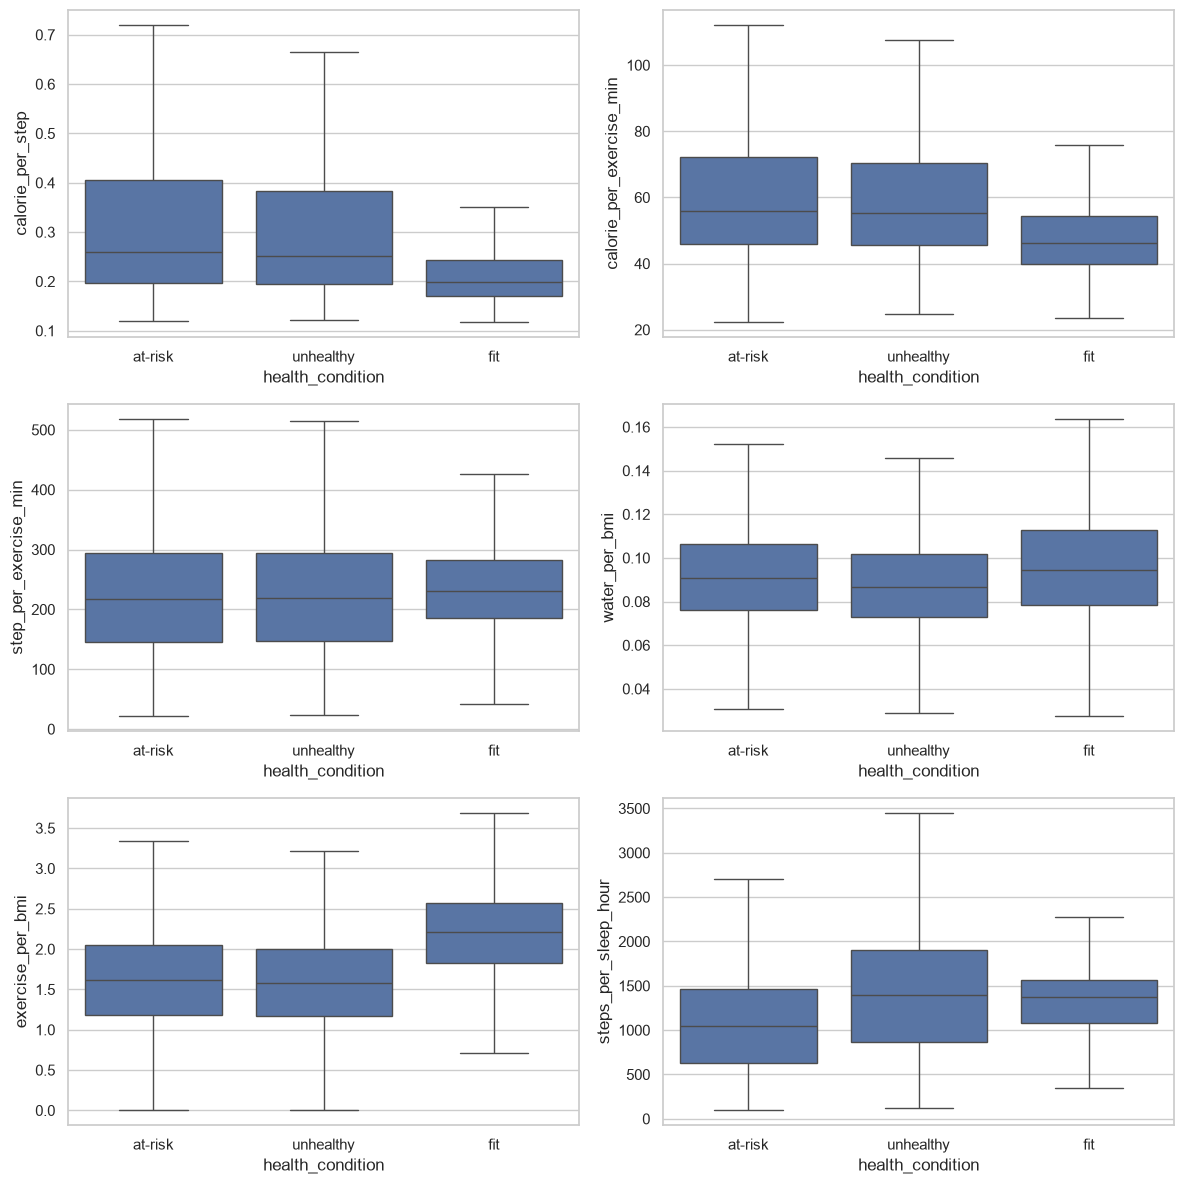

In [3]:
ratio_summary=train_fe.groupby(TARGET_COL)[ratio_cols].describe(percentiles=[.01,.05,.5,.95,.99]).T
display(ratio_summary); ratio_summary.to_csv(TABLES_DIR / "05_ratio_target_summary.csv")
plot_fe=train_fe.sample(min(PLOT_SAMPLE_SIZE,len(train_fe)),random_state=RANDOM_STATE)
fig,axes=plt.subplots(3,2,figsize=(12,12))
for col,ax in zip(ratio_cols,axes.flat):
    sns.boxplot(data=plot_fe,x=TARGET_COL,y=col,showfliers=False,ax=ax)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "05_ratio_by_target.png",dpi=150); plt.show()

## Interaction target tabloları

In [4]:
interaction_cols=["stress_sleep_quality","activity_diet","smoking_activity","gender_activity"]
interaction_tables=[]
for col in interaction_cols:
    table=pd.crosstab(train_fe[col],train_fe[TARGET_COL],normalize="index")
    table.insert(0,"feature",col); interaction_tables.append(table.reset_index())
    print(f"\n{col}"); display(table)
pd.concat(interaction_tables,ignore_index=True).to_csv(TABLES_DIR / "05_interaction_target.csv",index=False)


stress_sleep_quality


health_condition,feature,at-risk,fit,unhealthy
stress_sleep_quality,,,,
high__average,stress_sleep_quality,0.719527,0.003551,0.276922
high__good,stress_sleep_quality,0.893113,0.003606,0.103281
high__missing,stress_sleep_quality,0.718856,0.003206,0.277937
high__poor,stress_sleep_quality,0.564142,0.003469,0.432389
low__average,stress_sleep_quality,0.798401,0.198774,0.002826
low__good,stress_sleep_quality,0.720164,0.277166,0.002670
low__missing,stress_sleep_quality,0.795728,0.202164,0.002108
low__poor,stress_sleep_quality,0.874596,0.122390,0.003014
medium__average,stress_sleep_quality,0.993607,0.003104,0.003289



activity_diet


health_condition,feature,at-risk,fit,unhealthy
activity_diet,,,,
active__balanced,activity_diet,0.731283,0.179493,0.089225
active__missing,activity_diet,0.766935,0.155850,0.077215
active__non-veg,activity_diet,0.764972,0.153104,0.081924
active__veg,activity_diet,0.732724,0.182328,0.084947
missing__balanced,activity_diet,0.850054,0.063187,0.086759
missing__missing,activity_diet,0.864706,0.041176,0.094118
missing__non-veg,activity_diet,0.869216,0.051180,0.079604
missing__veg,activity_diet,0.859083,0.057563,0.083354
moderate__balanced,activity_diet,0.907567,0.002965,0.089469



smoking_activity


health_condition,feature,at-risk,fit,unhealthy
smoking_activity,,,,
missing__active,smoking_activity,0.736590,0.173362,0.090048
missing__missing,smoking_activity,0.856855,0.055108,0.088038
missing__moderate,smoking_activity,0.914686,0.003039,0.082275
missing__sedentary,smoking_activity,0.913806,0.002084,0.084110
no__active,smoking_activity,0.721108,0.225383,0.053509
no__moderate,smoking_activity,0.938316,0.004593,0.057091
no__sedentary,smoking_activity,0.943417,0.003374,0.053209
occasional__active,smoking_activity,0.743478,0.172578,0.083944
occasional__missing,smoking_activity,0.859534,0.057297,0.083170



gender_activity


health_condition,feature,at-risk,fit,unhealthy
gender_activity,,,,
female__active,gender_activity,0.743012,0.169337,0.087651
female__missing,gender_activity,0.858100,0.057422,0.084478
female__moderate,gender_activity,0.909023,0.002984,0.087993
female__sedentary,gender_activity,0.916340,0.002391,0.081269
male__active,gender_activity,0.735972,0.183696,0.080332
male__missing,gender_activity,0.860994,0.060257,0.078749
male__moderate,gender_activity,0.913810,0.003836,0.082353
male__sedentary,gender_activity,0.918206,0.002805,0.078990
missing__active,gender_activity,0.744999,0.166896,0.088105


## Rule-based flag target tabloları

In [5]:
rule_cols=["low_sleep_flag","high_sleep_flag","high_bmi_flag","low_bmi_flag",
           "high_heart_rate_flag","low_heart_rate_flag","low_steps_flag","high_steps_flag"]
rule_tables=[]
for col in rule_cols:
    table=pd.crosstab(train_fe[col],train_fe[TARGET_COL],normalize="index")
    table.insert(0,"feature",col); rule_tables.append(table.reset_index())
rule_target=pd.concat(rule_tables,ignore_index=True)
display(rule_target); rule_target.to_csv(TABLES_DIR / "05_rule_target.csv",index=False)

health_condition,low_sleep_flag,feature,at-risk,fit,unhealthy,high_sleep_flag,high_bmi_flag,low_bmi_flag,high_heart_rate_flag,low_heart_rate_flag,low_steps_flag,high_steps_flag
0,0.0,low_sleep_flag,0.914230,0.071113,0.014658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,low_sleep_flag,0.629734,0.002315,0.367951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,high_sleep_flag,0.857316,0.054928,0.087756,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,high_sleep_flag,0.885282,0.111555,0.003163,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,high_bmi_flag,0.860400,0.057822,0.081778,NaN,0.0,NaN,NaN,NaN,NaN,NaN
5,NaN,high_bmi_flag,0.168990,0.000000,0.831010,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,NaN,low_bmi_flag,0.860885,0.052487,0.086628,NaN,NaN,0.0,NaN,NaN,NaN,NaN
7,NaN,low_bmi_flag,0.796648,0.203352,0.000000,NaN,NaN,1.0,NaN,NaN,NaN,NaN
8,NaN,high_heart_rate_flag,0.858662,0.057676,0.083662,NaN,NaN,NaN,0.0,NaN,NaN,NaN
9,NaN,high_heart_rate_flag,0.915033,0.065359,0.019608,NaN,NaN,NaN,1.0,NaN,NaN,NaN


## Preprocessing karar matrisi

| Paket | İçerik | Karar amacı |
|---|---|---|
| V1 | Median, `missing`, missing flag | Güvenli baseline |
| V2 | V1 + ratio, count, interaction, outlier flag | İlk favori |
| V3 | V2 + train %0.1–%99.9 clipping | Ayrı deney |

Her adayı yalnız target ayrışması, train/test stabilitesi ve yorumlanabilirlik birlikte destekliyorsa `eda_findings.md` içinde kabul et.